# Assignment 6: Applying AI-Based Style Transfer to an Image

**Name:** Varshith Kumar R


**Class:** BCA

Compares two methods on the **same photo**:

1. **CycleGAN** – a pretrained generator that turns photos into paintings (Van Gogh by default).
2. **Neural Style Transfer (NST)** – VGG-19 feature matching (Gram matrices) with a painting of your choice.

Run the cells top to bottom (Runtime → Run all). Upload your photo when asked. A GPU (Runtime → Change runtime type → T4) makes NST much faster, but CPU also works with a small image size.

## 1. Setup

In [1]:
!pip -q install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 9.2 MB/s eta 0:00:00


In [2]:
import functools
import os
import sys
import urllib.request

import torch
import torch.nn as nn
from PIL import Image, ImageDraw
from torchvision import models, transforms as T

NETWORKS_URL = ("https://raw.githubusercontent.com/junyanz/"
                "pytorch-CycleGAN-and-pix2pix/master/models/networks.py")
CYCLEGAN_URL = "https://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/{}.pth"
DEFAULT_STYLE_URL = ("https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/"
                     "Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/"
                     "1280px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg")

DRAFT_COMPARISON = (
    "CycleGAN preserved the original content better. It is trained with a cycle-consistency "
    "loss: a photo translated into the painting domain by G and then back by F should "
    "reconstruct the original photo (F(G(x)) is approximately x), which stops the generator from "
    "changing the scene's structure, so objects and layout stay almost untouched and mostly "
    "colour and texture shift. "
    "Neural Style Transfer produced the stronger style transformation, because it matches "
    "Gram-matrix statistics of VGG-19 features to the chosen painting, so its brush strokes and "
    "colour patterns dominate the whole image. "
    "In short, CycleGAN gives a subtle, realistic result in a single fast forward pass using a "
    "learned painter-domain mapping, while NST gives a bolder, more abstract result for any "
    "painting but needs a slow per-image optimisation and can blur or distort fine details."
)

In [3]:
# ---- Settings you can change ----
CYCLEGAN_MODEL = "style_vangogh"   # style_monet | style_cezanne | style_ukiyoe | style_vangogh
IMAGE_SIZE = 512                   # longest side in pixels (use 256 if running on CPU)
NST_STEPS = 300                    # L-BFGS iterations for Neural Style Transfer
DRY_RUN = False                    # leave False; True only tests the code with random weights
OUT = "outputs"

os.makedirs(OUT, exist_ok=True)
WORK = os.path.join(OUT, "_cache")
os.makedirs(WORK, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [4]:
def download(url, path):
    if os.path.exists(path):
        return path
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (assignment6)"})
    with urllib.request.urlopen(req) as r, open(path, "wb") as f:
        f.write(r.read())
    return path


def load_image(path, size):
    img = Image.open(path).convert("RGB")
    w, h = img.size
    scale = size / max(w, h)
    # multiples of 4 so the CycleGAN encoder/decoder shapes match
    nw, nh = max(4, int(round(w * scale / 4)) * 4), max(4, int(round(h * scale / 4)) * 4)
    return img.resize((nw, nh), Image.LANCZOS)

## 2. Method 1 – CycleGAN

CycleGAN learns two generators, **G: photo → painting** and **F: painting → photo**, from *unpaired* images. The key idea is **cycle consistency**: translating a photo to the painting domain and back should give the original photo, `F(G(x)) ≈ x`. This loss stops the generator from changing the scene's structure arbitrarily, so content is preserved. Here only the trained photo → painting generator G is used (a single forward pass).

In [5]:
def run_cyclegan(img, model_name, device, workdir, dry_run=False):
    """Pretrained CycleGAN generator G: photo -> painting (ResNet, 9 blocks, instance norm)."""
    net_path = download(NETWORKS_URL, os.path.join(workdir, "networks.py"))
    sys.path.insert(0, os.path.dirname(os.path.abspath(net_path)))
    import networks  # official CycleGAN generator definition

    norm = functools.partial(nn.InstanceNorm2d, affine=False, track_running_stats=False)
    G = networks.ResnetGenerator(3, 3, 64, norm_layer=norm, use_dropout=False, n_blocks=9)
    if not dry_run:
        wpath = download(CYCLEGAN_URL.format(model_name),
                         os.path.join(workdir, f"{model_name}.pth"))
        sd = torch.load(wpath, map_location="cpu", weights_only=True)
        # old checkpoints store unused running stats for InstanceNorm; drop them
        sd = {k: v for k, v in sd.items()
              if not k.endswith(("running_mean", "running_var", "num_batches_tracked"))}
        G.load_state_dict(sd)
    G = G.to(device).eval()

    x = T.Compose([T.ToTensor(), T.Normalize((0.5,) * 3, (0.5,) * 3)])(img)[None].to(device)
    with torch.no_grad():
        y = G(x)[0].cpu()
    y = (y * 0.5 + 0.5).clamp(0, 1)
    return T.ToPILImage()(y)

## 3. Method 2 – Neural Style Transfer (VGG-19)

A pretrained VGG-19 is used only as a fixed feature extractor. Starting from the content image, the pixels themselves are optimised so that
* deep-layer features (relu4_2) match the **content** image, and
* Gram matrices of several layers (relu1_1 … relu5_1) match the **style** painting.

In [6]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
STYLE_LAYERS = [1, 6, 11, 20, 29]      # relu1_1, relu2_1, relu3_1, relu4_1, relu5_1
CONTENT_LAYER = 22                     # relu4_2


def gram(f):
    b, c, h, w = f.shape
    f = f.view(b, c, h * w)
    return f.bmm(f.transpose(1, 2)) / (c * h * w)


def vgg_features(vgg, x):
    out, last = {}, max(STYLE_LAYERS + [CONTENT_LAYER])
    for i, layer in enumerate(vgg):
        x = layer(x)
        if i in STYLE_LAYERS or i == CONTENT_LAYER:
            out[i] = x
        if i == last:
            break
    return out


def run_nst(content_img, style_img, device, steps=300, style_weight=1e6,
            content_weight=1.0, dry_run=False):
    """Gatys-style Neural Style Transfer with a VGG-19 feature extractor."""
    weights = None if dry_run else models.VGG19_Weights.IMAGENET1K_V1
    vgg = models.vgg19(weights=weights).features.to(device).eval()
    for m in vgg:
        if isinstance(m, nn.ReLU):
            m.inplace = False
    for p in vgg.parameters():
        p.requires_grad_(False)

    norm = T.Normalize(MEAN, STD)
    to_t = T.ToTensor()
    c = to_t(content_img)[None].to(device)
    s = to_t(style_img.resize(content_img.size, Image.LANCZOS))[None].to(device)

    with torch.no_grad():
        c_feat = vgg_features(vgg, norm(c))[CONTENT_LAYER]
        s_grams = {i: gram(f) for i, f in vgg_features(vgg, norm(s)).items() if i in STYLE_LAYERS}

    x = c.clone().requires_grad_(True)           # start from the content image
    opt = torch.optim.LBFGS([x], lr=1.0, max_iter=steps, max_eval=int(steps * 1.25))

    def closure():
        with torch.no_grad():
            x.clamp_(0, 1)
        opt.zero_grad()
        f = vgg_features(vgg, norm(x))
        c_loss = nn.functional.mse_loss(f[CONTENT_LAYER], c_feat)
        s_loss = sum(nn.functional.mse_loss(gram(f[i]), s_grams[i]) for i in STYLE_LAYERS)
        loss = content_weight * c_loss + style_weight * s_loss
        loss.backward()
        return loss

    opt.step(closure)
    with torch.no_grad():
        x.clamp_(0, 1)
    return T.ToPILImage()(x[0].detach().cpu())

## 4. Helpers for the side-by-side figure and the Word document

In [7]:
def side_by_side(images, labels, path, pad=12, label_h=34):
    w, h = images[0].size
    canvas = Image.new("RGB", (3 * w + 4 * pad, h + label_h + 2 * pad), "white")
    d = ImageDraw.Draw(canvas)
    for k, (im, lab) in enumerate(zip(images, labels)):
        x0 = pad + k * (w + pad)
        canvas.paste(im.resize((w, h)), (x0, pad + label_h))
        d.text((x0, pad + 8), lab, fill="black")
    canvas.save(path)


def build_docx(out_dir, info, comparison):
    from docx import Document
    from docx.enum.text import WD_ALIGN_PARAGRAPH
    from docx.shared import Inches, Pt

    doc = Document()
    doc.styles["Normal"].font.name = "Calibri"
    doc.styles["Normal"].font.size = Pt(11)
    doc.add_heading("Assignment 6: Applying AI-Based Style Transfer to an Image", level=1)
    doc.add_paragraph(
        f"Image: {info['content']}.  Method 1: pretrained CycleGAN ({info['cyclegan']}).  "
        f"Method 2: VGG-19 Neural Style Transfer with the painting \"{info['style']}\" "
        f"({info['steps']} L-BFGS steps).")

    table = doc.add_table(rows=2, cols=3)
    names = [("original.png", "1. Original image"),
             ("cyclegan.png", "2. CycleGAN output"),
             ("nst.png", "3. Neural Style Transfer output")]
    for col, (fn, cap) in enumerate(names):
        cell = table.cell(0, col)
        cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        cell.paragraphs[0].add_run().add_picture(os.path.join(out_dir, fn), width=Inches(2.0))
        capcell = table.cell(1, col).paragraphs[0]
        capcell.alignment = WD_ALIGN_PARAGRAPH.CENTER
        capcell.add_run(cap).bold = True

    doc.add_heading("Comparison", level=2)
    doc.add_paragraph(comparison)
    doc.save(os.path.join(out_dir, "Assignment6_Style_Transfer.docx"))

## 5. Choose the images
Run the next cell and upload **your photo** (landscape, building, object…). Optionally also upload a painting for NST; otherwise *Starry Night* is downloaded.

In [8]:
try:
    from google.colab import files
    print("Upload your photo:")
    up = files.upload()
    CONTENT_PATH = list(up.keys())[0]
except ImportError:
    CONTENT_PATH = "my_photo.jpg"      # running locally: put your photo next to the notebook

STYLE_PATH = None                      # set to a painting file name to use your own style image
if STYLE_PATH is None:
    STYLE_PATH = download(DEFAULT_STYLE_URL, os.path.join(WORK, "starry_night.jpg"))
print("Content:", CONTENT_PATH, "| Style:", STYLE_PATH)

Upload your photo:


Saving images (2).jpg to images (2).jpg
Content: images (2).jpg | Style: outputs/_cache/starry_night.jpg


## 6. Run both methods

In [9]:
content = load_image(CONTENT_PATH, IMAGE_SIZE)
style = Image.open(STYLE_PATH).convert("RGB")
content.save(os.path.join(OUT, "original.png"))

print("Running CycleGAN ...")
cg = run_cyclegan(content, CYCLEGAN_MODEL, device, WORK, DRY_RUN)
cg.save(os.path.join(OUT, "cyclegan.png"))

print("Running Neural Style Transfer (this takes a while) ...")
nst_img = run_nst(content, style, device, steps=NST_STEPS, dry_run=DRY_RUN)
nst_img.save(os.path.join(OUT, "nst.png"))
print("Done.")

Running CycleGAN ...
Running Neural Style Transfer (this takes a while) ...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 188MB/s]


Done.


## 7. Original | CycleGAN | Neural Style Transfer

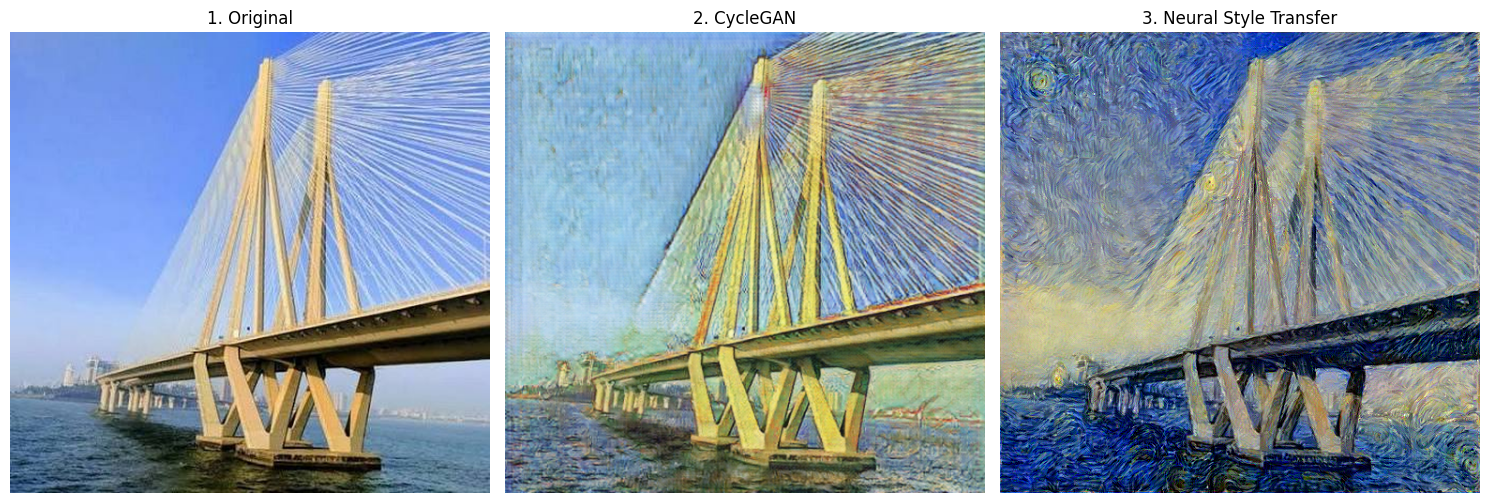

In [10]:
import matplotlib.pyplot as plt

side_by_side([content, cg, nst_img], ["Original", "CycleGAN", "Neural Style Transfer"],
             os.path.join(OUT, "side_by_side.png"))
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a_, im, t in zip(ax, [content, cg, nst_img], ["1. Original", "2. CycleGAN", "3. Neural Style Transfer"]):
    a_.imshow(im); a_.set_title(t); a_.axis("off")
plt.tight_layout(); plt.show()

## 8. Written comparison
Look at your own outputs, then **edit this text** so it matches what you actually observe (the draft below describes the typical result).

In [11]:
COMPARISON = DRAFT_COMPARISON
# COMPARISON = """write your own 3-4 lines here"""
print(COMPARISON)

CycleGAN preserved the original content better. It is trained with a cycle-consistency loss: a photo translated into the painting domain by G and then back by F should reconstruct the original photo (F(G(x)) is approximately x), which stops the generator from changing the scene's structure, so objects and layout stay almost untouched and mostly colour and texture shift. Neural Style Transfer produced the stronger style transformation, because it matches Gram-matrix statistics of VGG-19 features to the chosen painting, so its brush strokes and colour patterns dominate the whole image. In short, CycleGAN gives a subtle, realistic result in a single fast forward pass using a learned painter-domain mapping, while NST gives a bolder, more abstract result for any painting but needs a slow per-image optimisation and can blur or distort fine details.


## 9. Build and download the submission document

In [12]:
build_docx(OUT, {"content": os.path.basename(CONTENT_PATH), "cyclegan": CYCLEGAN_MODEL,
                 "style": os.path.splitext(os.path.basename(STYLE_PATH))[0].replace("_", " "),
                 "steps": NST_STEPS}, COMPARISON)
docx_path = os.path.join(OUT, "Assignment6_Style_Transfer.docx")
print("Saved", docx_path)
try:
    from google.colab import files
    files.download(docx_path)
except ImportError:
    pass

Saved outputs/Assignment6_Style_Transfer.docx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>